In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/Users/edabier/miniconda3/envs/hsu-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/edabier/miniconda3/envs/hsu-env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


False


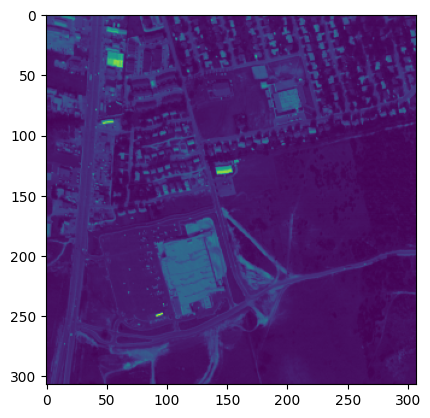

In [3]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]

Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
H, W = Y.shape[1], Y.shape[2]

patch_size_cnn = 10
patch_size = 10

plt.imshow(Y.cpu()[10,:,:])

In [4]:
# dataset_full = utils.HSI_dataset(dataset=dataset)
# dataset_patched = utils.HSI_dataset(dataset=dataset, patch_size=patch_size)
# full_loader = DataLoader(dataset_full)
# patched_loader = DataLoader(dataset_patched)

full_loader, _, _ = utils.create_dataloader(dataset, dev)
patched_loader, test_loader, B, _ = utils.create_dataloader(dataset, dev, 0.7, patch_size)

## Models

### MLP AE ✅

In [5]:
mlpae = models.MLAP_AE(B=B, c=c)
sum(p.numel() for p in mlpae.parameters() if p.requires_grad)

160044

### CNNAE + linear mapping ✅
*Needs small patch size for memory (decoder of shape $patch^2 * c \times patch^2 * B$)*

In [6]:
cnnlinear = models.CNNAE_linear(B=B, c=c, patch_size=patch_size_cnn)
sum(p.numel() for p in cnnlinear.parameters() if p.requires_grad)

9806580

### CNNAEU ✅

In [7]:
cnnaeu = models.CNNAEU(B=B, c =c)
sum(p.numel() for p in cnnaeu.parameters() if p.requires_grad)

187992

### Transformer AE ✅
*Accepts higher patch sizes than CNN linear*

In [8]:
Y_trans = Y[:,:patch_size,:patch_size]
transformer_patched = models.Transformer_AE(B=B, c=c, im_size=Y_trans.shape[1], dim=200)
sum(p.numel() for p in transformer_patched.parameters() if p.requires_grad)

11660546

### NALMU ✅

In [9]:
nalmu_full = models.NALMU(B=B, c=c, N=N)
nalmu_patched = models.NALMU(B=B, c=c, N=patch_size**2)
sum(p.numel() for p in nalmu_full.parameters() if p.requires_grad)

5664660

### RALMU ✅

In [10]:
ralmu_full = models.RALMU(B=B, c=c, im_size=H)
ralmu_patched = models.RALMU(B=B, c=c, im_size=patch_size)
sum(p.numel() for p in ralmu_full.parameters() if p.requires_grad)

2274170

## SSL methods

In [11]:
model = cnnaeu
epochs = 100
lr = 1e-1

### Reconstruction error

In [12]:
# re_trainer = ssl.ReconstructionError(model, epochs=epochs, lr=lr)
# e_hat_re, a_hat_re, train_losses_re = re_trainer.train(full_loader)
# print(e_hat_re.shape, a_hat_re.shape)

# plt.plot(train_losses_re)

### DIP

In [13]:
# dip_trainer = ssl.DIP(model, epochs=epochs, lr=lr)
# e_hat_dip, a_hat_dip, train_losses_dip = dip_trainer.train(full_loader)
# print(e_hat_dip.shape, a_hat_dip.shape)

# plt.plot(train_losses_dip)

### Two stages net

In [14]:
# two_s_trainer = ssl.TwoStagesNet(model, B, epochs=epochs, lr=lr)
# e_hat_twos, a_hat_twos, train_losses_twos = two_s_trainer.train(full_loader)
# print(e_hat_twos.shape, a_hat_twos.shape)

# plt.plot(train_losses_twos)

### Generating dataset

In [15]:
# generate_dataset_trainer = ssl.GeneratedDataset(model)
# generate_dataset_trainer.generate_dataset(Y, c=E.shape[1])
# generate_dataset_trainer.train(Y)

### Testing learned model:

In [16]:
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
model.load_state_dict(torch.load("models/CNNAEU_TWOS_lr_0.1_checkpoint.pt")["model_state_dict"], strict=False)
e_hat, a_hat, y_hat = model.forward(Y)

if e_hat.dim() == 3:
    e_hat = e_hat.squeeze(0)
    
# model = cnnaeu
# re, sad = utils.test_model(model, full_loader)
# print(re, sad)

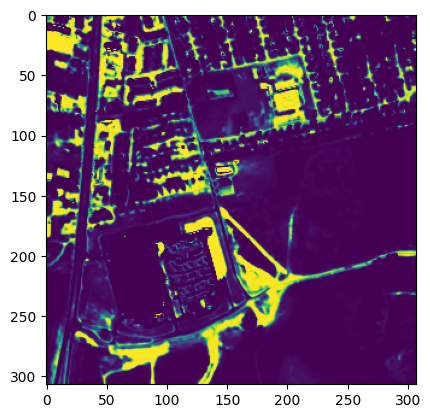

In [17]:
"""
Display extracted abundance matrix
"""
plt.imshow(a_hat.reshape(a_hat.shape[1], int(a_hat.shape[2]**0.5), int(a_hat.shape[2]**0.5))[0].detach())

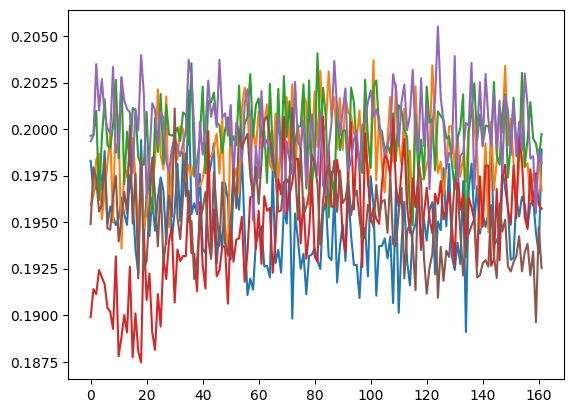

In [18]:
"""
Display extracted endmembers
"""
for i in range(c):
    plt.plot(e_hat[:,i].detach())
plt.show()